# Section 3.2 — Confidence intervals

This notebook contains the code examples from [Section 3.2 Confidence intervals]() of the **No Bullshit Guide to Statistics**. Use the "rocket" icon at the top-right to make the code cells interactive (Live Code), or run this notebook an ephemeral JupyterLab cloud instance (Binder).

#### Notebook setup

In [1]:
%pip install -q numpy scipy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
# load Python modules
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Plot helper functions
from ministats import plot_pdf

In [4]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"font.family": "serif",
        "font.serif": ["Palatino", "DejaVu Serif", "serif"],
        "figure.figsize": (6, 1.4)},
)
%config InlineBackend.figure_format = 'retina'

<Figure size 640x480 with 0 Axes>

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


In [6]:
# Simple float __repr__  
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

# set random seed for repeatability
np.random.seed(42)

$\def\stderr#1{\mathbf{se}_{#1}}$
$\def\stderrhat#1{\hat{\mathbf{se}}_{#1}}$
$\newcommand{\Mean}{\textbf{Mean}}$
$\newcommand{\Var}{\textbf{Var}}$
$\newcommand{\Std}{\textbf{Std}}$
$\newcommand{\Freq}{\textbf{Freq}}$
$\newcommand{\RelFreq}{\textbf{RelFreq}}$
$\newcommand{\DMeans}{\textbf{DMeans}}$
$\newcommand{\Prop}{\textbf{Prop}}$
$\newcommand{\DProps}{\textbf{DProps}}$

$$
\newcommand{\CI}[1]{\textbf{CI}_{#1}}
\newcommand{\CIL}[1]{\textbf{L}_{#1}}
\newcommand{\CIU}[1]{\textbf{U}_{#1}}
\newcommand{\ci}[1]{\textbf{ci}_{#1}}
\newcommand{\cil}[1]{\textbf{l}_{#1}}
\newcommand{\ciu}[1]{\textbf{u}_{#1}}
$$


(this cell contains the macro definitions like $\stderr{\overline{\mathbf{x}}}$, $\stderrhat{}$, $\Mean$, ...)

## Definitions



### Review of estimators

Recall all the estimators (functions that take samples as inputs) we defined in the previous section.

In [7]:
def mean(sample):
    return sum(sample) / len(sample)

def var(sample):
    xbar = mean(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

def std(sample):
    s2 = var(sample)
    return np.sqrt(s2)

def dmeans(xsample, ysample):
    dhat = mean(xsample) - mean(ysample)
    return dhat

### Interpreting confidence intervals


Illustration of 90% confidence intervals for the population mean.
The plot shows confidence intervals 
$\ci{\theta,0.9,1}$, $\ci{\theta,0.9,2}$, $\ci{\theta,0.9,3}$, $\ldots$,
$\ci{\theta,0.9,50}$,
which we computed from 50 different samples
of size $n=20$ taken from the population $X \sim \mathcal{N}(100,10)$.
The true population mean is $\mu_X = 100$.
Intervals that don't include $\mu_X$ are drawn in light red.
      
![](./attachments/confidence_intervals_mean_rvX_n20.png)

## Confidence interval constructions

Ingredients:

- knowledge of the sampling distribution $\widehat{\Theta}$ of the estimator
- knowledge of the inverse cumulative distribution function (inverse-CDF)
  of the sampling distributions $F^{-1}_{\widehat{\Theta}}$

Procedure:

- calculate the $\tfrac{\alpha}{2}$-quantile, 
  $F^{-1}_{\widehat{\Theta}}(\tfrac{\alpha}{2})$,
  and the $(1-\tfrac{\alpha}{2})$-quantile,
  $F^{-1}_{\widehat{\Theta}}(1-\tfrac{\alpha}{2})$
  of the sampling distribution
- use a pivotal quantity to convert the quantiles of the sampling distribution
  and obtain the lower bound and upper bounds of the confidence interval


Recall the two methods for approximating sampling distributions:
analytical approximation formulas (based on probability distributions)
and the bootstrap estimation procedure (based on computation),
which we learned in [Section 3.1](./31_estimators.ipynb).
We'll now learn how to compute confidence intervals based on these approximation methods.

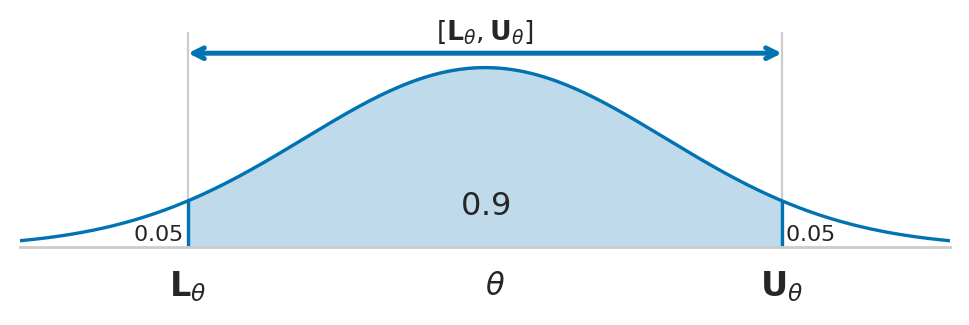

In [8]:
from ministats.book.figures import plot_confidence_interval
plot_confidence_interval();

### Bootstrap confidence intervals

In [9]:
np.random.seed(42)
xsample = [1,2,3,4,5]
mean(xsample)

3.0

In [10]:
from ministats import gen_boot_dist
xbars_boot = gen_boot_dist(xsample, estfunc=mean, B=100)
xbars_boot[0:5]  # first five bootstrap means

[4.4, 3.2, 3.6, 3.2, 2.6]

In [11]:
[np.percentile(xbars_boot,5), np.percentile(xbars_boot,95)]

[1.8, 4.2]

In [12]:
[np.quantile(xbars_boot,0.05), np.quantile(xbars_boot,0.95)]

[1.8, 4.2]

### Analytical approximations

$$
    z_\ell = F_{Z}^{-1}(\tfrac{\alpha}{2})
    \qquad \text{and} \qquad
    z_u = F_{Z}^{-1}(1-\tfrac{\alpha}{2}).
$$

In [13]:
from scipy.stats import norm

rvZ = norm(loc=0, scale=1)
z_u = rvZ.ppf(0.95)
z_u

1.644853626951472

In [14]:
rvZ = norm(0, 1)
z_u = rvZ.ppf(0.95)
z_u

1.644853626951472

#### Default parameters

In [15]:
rvZ = norm()
z_u = rvZ.ppf(0.95)
z_u

1.644853626951472

#### Class methods

In [16]:
z_u = norm.ppf(0.95, loc=0, scale=1)
z_u

1.644853626951472

In [17]:
z_u = norm.ppf(0.95)
z_u

1.644853626951472

#### Construct 90% confidence interval for the Z distribution

In [18]:
alpha = 0.1
z_l = norm.ppf(alpha/2)
z_u = norm.ppf(1-alpha/2)
[z_l, z_u]

[-1.6448536269514729, 1.644853626951472]

#### Other standard reference distributions

Just call class method, since by default `loc=0` and `scale=1`.

In [19]:
# 95th percentile of the t distribution
from scipy.stats import t as tdist
rvT = tdist(df=6, loc=0, scale=1)
rvT.ppf(0.95)

1.9431802805153042

In [20]:
# 95th percentile of the chi-square distribution
from scipy.stats import chi2
rvQ = chi2(df=6, loc=0, scale=1)
rvQ.ppf(0.95)

12.591587243743977

## Confidence interval for the population mean

$$
    T = \frac{\overline{\mathbf{X}} - \mu_X}{ \stderrhat{\overline{\mathbf{x}}} }
    \sim \mathcal{T}(n-1).
$$

To build a $(1-\alpha)$ confidence interval,
we first calculate the $\frac{\alpha}{2}$ and $(1-\frac{\alpha}{2})$ quantiles of Student's $t$-distribution:

$$
    t_\ell = F_{T}^{-1}(\tfrac{\alpha}{2})
    \qquad \text{and} \qquad
    t_u = F_{T}^{-1}(1-\tfrac{\alpha}{2}).
$$

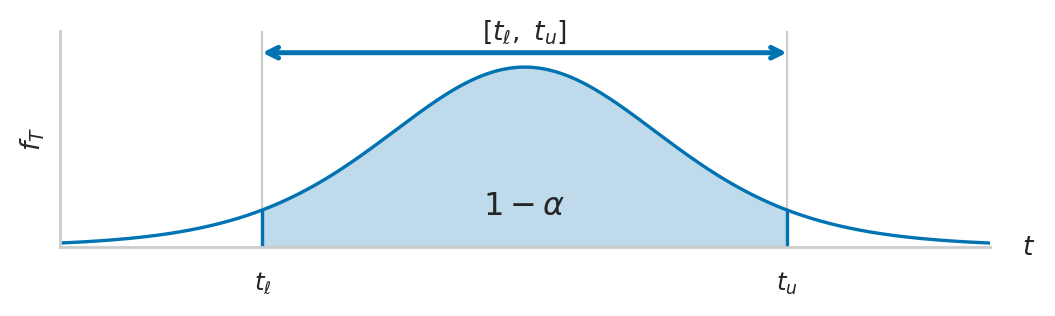

In [21]:
from ministats import plot_conf_int
from scipy.stats import t as tdist

rvT = tdist(df=9)
plot_conf_int(rvT, alpha=0.1, rv_name="T");

### Example 1: confidence interval for the mean apple weight

In [22]:
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]
asample.values

array([205., 182., 192., 189., 217., 192., 210., 240., 225., 191., 193.,
       209., 167., 183., 210., 198., 239., 188., 179., 182., 200., 197.,
       245., 192., 201., 218., 198., 211., 208., 217.])

The sample mean is:

In [23]:
abar = mean(asample)
abar

202.6

#### Analytical confidence interval for the mean

In [24]:
n = len(asample)
n

30

In [25]:
sehatAbar = std(asample) / np.sqrt(n)
sehatAbar

3.3959407817427336

In [26]:
from scipy.stats import t as tdist
rvT = tdist(df=n-1)
t_05 = rvT.ppf(0.05)
t_95 = rvT.ppf(0.95)

[abar + t_05*sehatAbar, abar + t_95*sehatAbar]

[196.82986523723363, 208.37013476276636]

We would normally report this interval as $[197, 208]$ without too many decimals.

#### Bootstrap confidence interval for the mean

In [27]:
np.random.seed(50)

# generate the bootstrap distribution of the mean
abars_boot = gen_boot_dist(asample, estfunc=mean)

# construct the confidence interval
[np.percentile(abars_boot,5), np.percentile(abars_boot,95)]

[197.23333333333332, 208.26666666666668]

### Reusable procedure

In [28]:
def ci_mean(sample, alpha=0.1, method="a"):
    """
    Compute confidence interval for the population mean.
    - method="a" analytical approx. based on Student's t-dist
    - method="b" approx. based on bootstrap estimation
    """
    assert method in ["a", "b"]
    if method == "a":        # analytical approximation
        from scipy.stats import t as tdist
        n = len(sample)
        xbar = np.mean(sample)
        sehat = np.std(sample, ddof=1) / np.sqrt(n)
        t_l = tdist(df=n-1).ppf(alpha/2)
        t_u = tdist(df=n-1).ppf(1-alpha/2)
        return [xbar + t_l*sehat, xbar + t_u*sehat]
    elif method == "b":          # bootstrap estimation
        xbars_boot = gen_boot_dist(sample, estfunc=mean)
        return [np.quantile(xbars_boot, alpha/2),
                np.quantile(xbars_boot, 1-alpha/2)]

# ALT.
# from ministats import ci_mean

### Verify coverage probability

In [29]:
np.random.seed(42)

N = 100  # change to N=1000 for more accuracy
n = 20

from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

acount, bcount = 0, 0
for j in range(0, N):
    ksample = rvK.rvs(n)
    cia = ci_mean(ksample, alpha=0.1, method="a")
    if cia[0] <= muK <= cia[1]:
        acount += 1
    cib = ci_mean(ksample, alpha=0.1, method="b")
    if cib[0] <= muK <= cib[1]:
        bcount += 1

print("Coverage proportion of analytical approx. CIs:", acount / N)
print("Coverage proportion of bootstrap CIs:", bcount / N)

Coverage proportion of analytical approx. CIs: 0.89
Coverage proportion of bootstrap CIs: 0.86


## Confidence interval for the population variance

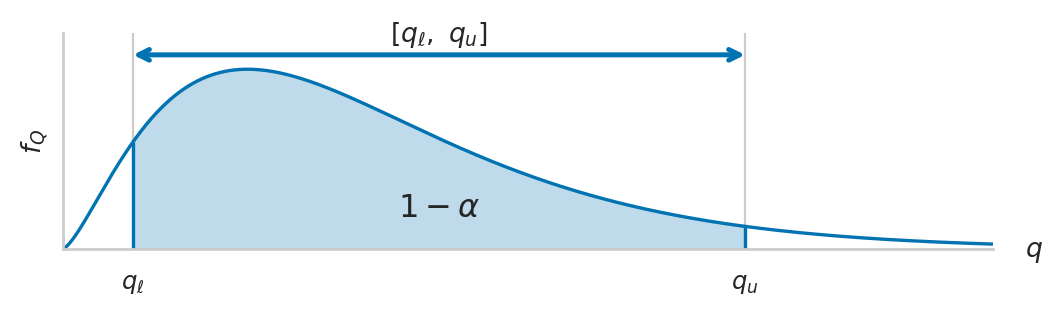

In [30]:
from ministats import plot_conf_int
from scipy.stats import chi2

rvX2 = chi2(df=5)
plot_conf_int(rvX2, alpha=0.1, rv_name="Q");

### Example 2: confidence interval for the variance of apple weights

In [31]:
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]
n = len(asample)
n

30

In [32]:
s2 = var(asample)
s2

345.9724137931035

In [33]:
from scipy.stats import chi2
rvX2 = chi2(df=n-1, loc=0, scale=1)
q_05 = rvX2.ppf(0.05)
q_95 = rvX2.ppf(0.95)
[(n-1)*s2/q_95, (n-1)*s2/q_05]

[235.75927791988897, 566.5796548600426]

#### Bootstrap confidence interval for the variance

In [34]:
np.random.seed(53)

# generate the bootstrap distribution of the variance
avars_boot = gen_boot_dist(asample, estfunc=var)

# construct the confidence interval
[np.percentile(avars_boot,5),
 np.percentile(avars_boot,95)]

[196.387816091954, 480.82183908046]

### Reusable procedure

In [35]:
def ci_var(sample, alpha=0.1, method="a"):
    """
    Compute confidence interval for the population variance.
    - method="a" analytical approx. based on chi-square dist
    - method="b" approx. based on bootstrap estimation
    """
    assert method in ["a", "b"]
    if method == "a":        # analytical approximation
        n = len(sample)
        s2 = np.var(sample, ddof=1)
        q_l = chi2(df=n-1).ppf(alpha/2)
        q_u = chi2(df=n-1).ppf(1-alpha/2)
        return [(n-1)*s2/q_u, (n-1)*s2/q_l]
    elif method == "b":          # bootstrap estimation
        vars_boot = gen_boot_dist(sample, estfunc=var)
        return [np.quantile(vars_boot, alpha/2),
                np.quantile(vars_boot, 1-alpha/2)]

# ALT.
# from ministats import ci_var

### Verify coverage probability

In [36]:
np.random.seed(42)

N = 100  # change to N=1000 for more accuracty
n = 20

from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

acount, bcount = 0, 0
for j in range(0, N):
    ksample = rvK.rvs(n)
    cia = ci_var(ksample, alpha=0.1, method="a")
    if cia[0] <= sigmaK**2 <= cia[1]:
        acount += 1
    cib = ci_var(ksample, alpha=0.1, method="b")
    if cib[0] <= sigmaK**2 <= cib[1]:
        bcount += 1

print("Coverage proportion of analytical approx. CIs:", acount/N)
print("Coverage proportion of bootstrap CIs:", bcount/N)

Coverage proportion of analytical approx. CIs: 0.89
Coverage proportion of bootstrap CIs: 0.81


## Confidence interval for the difference between means

### Example 3: confidence interval for difference in electricity prices

In [37]:
eprices = pd.read_csv("datasets/eprices.csv")
pricesW = eprices[eprices["loc"]=="West"]["price"]
pricesE = eprices[eprices["loc"]=="East"]["price"]

The difference between sample means $\hat{d} = \overline{\mathbf{x}}_W - \overline{\mathbf{x}}_E$ is:

In [38]:
dhat = dmeans(pricesW, pricesE)
dhat

3.0000000000000018

The estimate $\hat{d}$ will be the center of the confidence interval.

Now let's compute the parameters we need to know to calculate the standard error
of the sampling distribution.

In [39]:
# sample size and std in West and East
stdW, nW = pricesW.std(), len(pricesW)
stdE, nE = pricesE.std(), len(pricesE)
stdW, nW, stdE, nE

(1.5621388471508475, 9, 0.8776547030454391, 9)

In [40]:
# standard error
seD = np.sqrt(stdW**2/nW + stdE**2/nE)
seD

0.5972674401486562

In [41]:
# degrees of freedom
from ministats import calcdf

dfD = calcdf(stdW, nW, stdE, nE)
dfD

12.59281702723103

In [42]:
from scipy.stats import t as tdist

# calculate the quantiles of the t-distribution 
rvT = tdist(df=dfD)
t_05 = rvT.ppf(0.05)
t_95 = rvT.ppf(0.95)

# construct the confidence interval
[dhat + t_05*seD, dhat + t_95*seD]

[1.9396575883680873, 4.0603424116319164]

#### Bootstrap confidence interval

In [43]:
# compute bootstrap estimates for mean in each group
np.random.seed(42)
meanW_boot = gen_boot_dist(pricesW, estfunc=mean)
meanE_boot = gen_boot_dist(pricesE, estfunc=mean)

# compute the difference between means of bootstrap samples
dmeans_boot = np.subtract(meanW_boot, meanE_boot)

# construct the confidence interval
[np.percentile(dmeans_boot,5),
 np.percentile(dmeans_boot,95)]

[2.0666666666666664, 3.933888888888892]

### Reusable procedure

In [44]:
def ci_dmeans(xsample, ysample, alpha=0.1, method="a"):
    """
    Compute confidence interval for the difference between population means.
    - method="a" analytical approx. based on Student's t-dist
    - method="b" approx. based on bootstrap estimation
    """
    assert method in ["a", "b"]
    if method == "a":        # analytical approximation
        stdX, n = np.std(xsample, ddof=1), len(xsample)
        stdY, m = np.std(ysample, ddof=1), len(ysample)
        dhat = np.mean(xsample) - np.mean(ysample)
        seD = np.sqrt(stdX**2/n + stdY**2/m)
        dfD = calcdf(stdX, n, stdY, m)
        t_l = tdist(df=dfD).ppf(alpha/2)
        t_u = tdist(df=dfD).ppf(1-alpha/2)
        return [dhat + t_l*seD, dhat + t_u*seD]
    elif method == "b":          # bootstrap estimation
        xbars_boot = gen_boot_dist(xsample, np.mean)
        ybars_boot = gen_boot_dist(ysample, np.mean)
        dmeans_boot = np.subtract(xbars_boot,ybars_boot)
        return [np.quantile(dmeans_boot, alpha/2),
                np.quantile(dmeans_boot, 1-alpha/2)]

# ALT.
# from ministats import ci_dmeans

### Verify the coverage probability

In [45]:
np.random.seed(42)

N = 100  # change to N=1000 for more accuracty
n = 20

from scipy.stats import norm
muX, muY = 120, 100
sigmaX, sigmaY = 10, 10
rvX = norm(muX, sigmaX)
rvY = norm(muY, sigmaY)

acount, bcount = 0, 0
for j in range(0, N):
    xsample = rvX.rvs(n)
    ysample = rvY.rvs(n)
    cia = ci_dmeans(xsample, ysample, alpha=0.1, method="a")
    if cia[0] <= muX - muY <= cia[1]:
        acount += 1
    cib = ci_dmeans(xsample, ysample, alpha=0.1, method="b")
    if cib[0] <= muX - muY <= cib[1]:
        bcount += 1

print("Coverage proportion of analytical approx. CIs:", acount/N)
print("Coverage proportion of bootstrap CIs:", bcount/N)

Coverage proportion of analytical approx. CIs: 0.85
Coverage proportion of bootstrap CIs: 0.84


## Alternative calculation methods

### Using `scipy.stats.bootstrap` for confidence intervals

#### One-sample bootstrap confidence interval

In [46]:
from scipy.stats import bootstrap

np.random.seed(50)
res = bootstrap([asample], statistic=mean,
                confidence_level=0.9, n_resamples=5000,
                vectorized=False, method="percentile")
[res.confidence_interval.low,
 res.confidence_interval.high]

[197.23333333333332, 208.26666666666668]

Note the result is the same as ...

Using the function `scipy.stats.bootstrap` requires lots of keyword arguments,
because it is a very powerful tool you can use for all kinds of bootstrap calculations.
Let's go over the arguments one by one:

- Instead of giving the input `asample` directly as the first argument,
  we pass in a list of length one `[asample]`
  which tells the function that we want a single-sample calculation
- `statistic`: specify the estimator we want to compute confidence interval for
- `confidence_level`: the confidence level $(1-\alpha)$
- `n_resamples`: the number of bootstrap samples we want to generate
- `vectorized=False`: turns off vectorized inputs,
  which is a performance optimization that we don't need for this calculation
- `method="percentile"`: select the percentile bootstrap method,
  as opposed to one of the other bootstrap methods that are available

The `bootstrap` function returns a result object. We can access the attributes of this object to obtain the limits of the confidence interval. Note the result is identical to the bootstrap estimate we obtained from the function `gen_boot_dist` followed by `np.percentile` calculations.

#### Two-sample bootstrap confidence interval?

In [47]:
# two-sample test `scipy.stats`
from scipy.stats import bootstrap

np.random.seed(42)
res = bootstrap([pricesW, pricesE], statistic=dmeans,
                confidence_level=0.9, n_resamples=5000,
                vectorized=False, method="percentile")
[res.confidence_interval.low,
 res.confidence_interval.high]

[2.0666666666666664, 3.933888888888892]

Note the result is the same as ...

### Using `statsmodels` for confidence intervals

The Python libraries `statsmodels`, `scipy.stats`, and `pingouin`
provide predefined functions for computing confidence intervals.
We'll now show some of these "alternative computations"
based on predefined functions so you'll learn a little bit
about the tools for statistical analysis that are available to you.

We'll also use these alternative computations to confirm
that the calculations we did from first principles are correct.

Note however these are "optional" reading materials, and you can skip
any code cells that start with an `# ALT` comment without loss of generality.

In [48]:
import statsmodels.stats.api as sms
sms.DescrStatsW(asample).tconfint_mean(alpha=0.1)

(196.82986523723363, 208.37013476276636)

#### Two-sample confidence intervals

In [49]:
import statsmodels.stats.api as sms

statsW = sms.DescrStatsW(pricesW)
statsE = sms.DescrStatsW(pricesE)
cm = sms.CompareMeans(statsW, statsE)
cm.tconfint_diff(alpha=0.1, usevar="unequal")

(1.9396575883680873, 4.060342411631915)

Note the result is the same as ...

In the above code example, the functions `sms.DescrStatsW` compute the descriptive statistics
for the two samples, then `sms.CompareMeans` performs the comparison of means statistical analysis.
We call the method `tconfint_diff` to extract the 90\% confidence interval from the result.

As you can see,
the numbers we obtain from the `statsmodels`
is exactly the same as the confidence interval we computed manually.

### Using `pingouin` for confidence intervals

In [50]:
import pingouin as pg

pg.compute_bootci(asample, func=mean,
                  confidence=0.9, n_boot=5000,
                  method="per", seed=50)

array([197.27, 208.3 ])

In [51]:
import pingouin as pg

res = pg.ttest(pricesW, pricesE, confidence=0.9, correction=True)
res["CI90"].values[0]

array([1.93965759, 4.06034241])

Note the results are the same as ...

## Explanations

### One-sided confidence intervals

In [52]:
# TODO add code example

### Point and interval estimates

terminology...


### Frequentist interpretation

Guarantees for confidence intervals given in terms of $\mathbb{E}_\mathbf{X}$, the expectation over a random sample $\mathbf{X}$. These guarantees can be interpreted as long-term average error rates if the statistical procedure were performed many times (frequentist paradigm).
Note in the frequentist paradigm gives no guarantee about any specific confidence interval—only gives guarantee about the performance of the procedure we used for computing the CIs.

### Assumptions

condensed mention of:    (full discussion of assumptions in Sec 3.4)
Parametric model assumption (conceptual)  cf. nonparametric methods

- (NORM): the population is normally distributed (normality test)
- (LARGEn): the sample size is “large enough” for approximate normality
- (EQVAR): the variance in two groups is the same


## Discussion

### Misconceptions about confidence intervals

See main text.

### Comparing analytical formulas and bootstrap estimates

See main text.

### Advanced bootstrap methods

Mention more advanced bootstrap methods like BCa exist (--> see problem PZZ)

In [53]:
# BCa = Bias-Corrected accelerated mean
from scipy.stats import bootstrap

np.random.seed(53)
res = bootstrap([asample], statistic=mean,
                confidence_level=0.9, n_resamples=5000,
                vectorized=False, method="bca")

# sns.histplot(res.bootstrap_distribution, bins=30)

[res.confidence_interval.low,
 res.confidence_interval.high]

[197.6, 208.46666666666664]

In [54]:
# BCa = Bias-Corrected accelerated var
from scipy.stats import bootstrap

np.random.seed(53)
res = bootstrap([asample], statistic=var,
                confidence_level=0.9, n_resamples=5000,
                vectorized=False, method="bca")

# sns.histplot(res.bootstrap_distribution, bins=30)

[res.confidence_interval.low,
 res.confidence_interval.high]

[231.29845557680545, 541.41793330525]

This interval is very close to the analytical approximation we obtained
in terms of the chi-square reference distribution $[235.8, 566.6]$.

### Evaluation of confidence interval methods

Rows:
- uniform
- norm
- slightly skewed
- very skewed 
- bimodal

Column groups:
- coverage probability
- average width

Cols:
- analytical approx
- percentile bootstrap
- BCa



In [55]:
from scipy.stats import uniform, norm, lognorm, expon
from ministats.probs import mixnorms

# different populations to use for simulation
POPULATIONS = {      
    "Z": norm(),
    "U": uniform(),
    "S": lognorm(s=0.3),
    "E": expon(loc=0, scale=1/5),
    "B": mixnorms(locs=[3,6.2], scales=[1,1], weights=[0.4,0.6]),
}

METHODS = [
    "a",           # analytical approximation
    "percentile",  # percentile bootstrap
    "bca",         # bias-corrected accelerated bootstrap
]

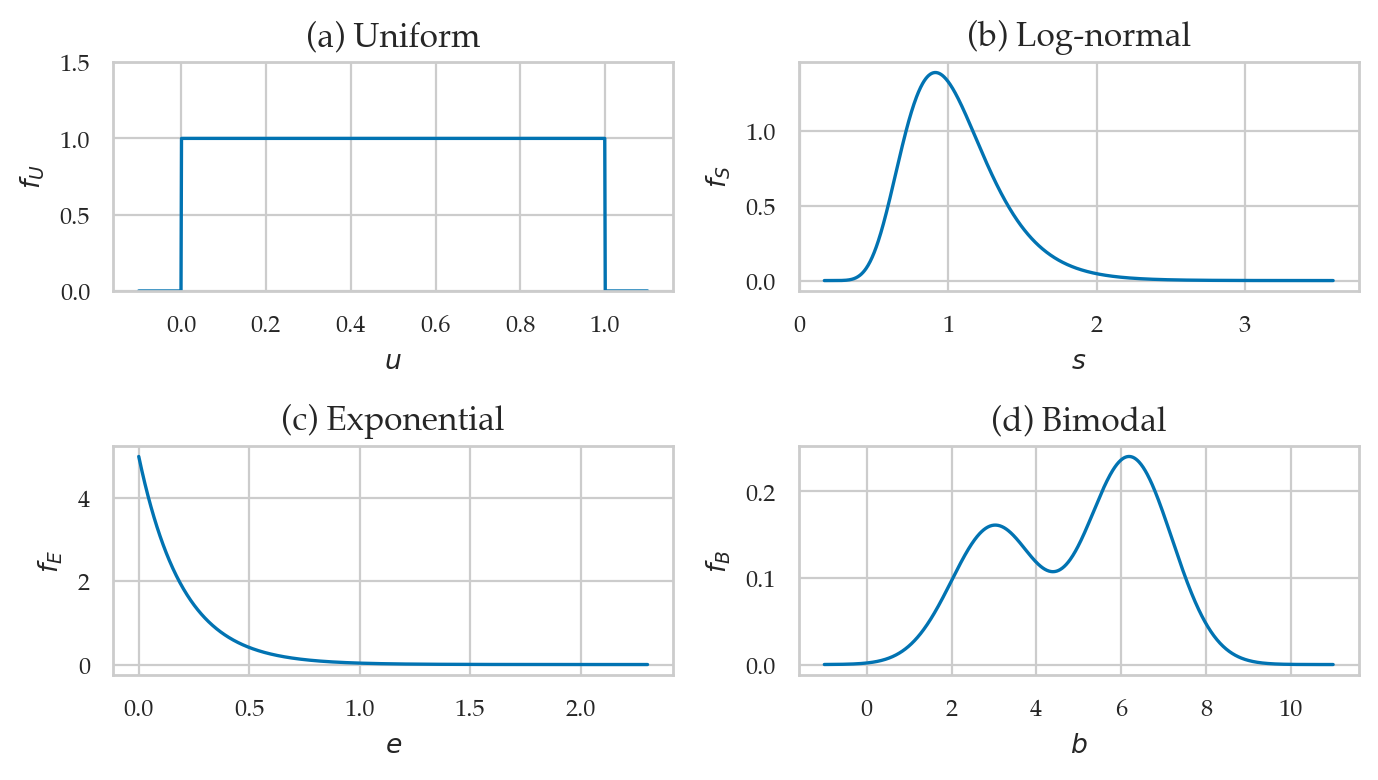

In [77]:
fig, axs = plt.subplots(2, 2, figsize=(7,4))

# Uniform
rvU = POPULATIONS["U"]
plot_pdf(rvU, ax=axs[0,0], xlims=[-0.1, 1.1], rv_name="U")
axs[0,0].set_ylim(0,1.5)
axs[0,0].set_title("(a) Uniform", fontsize=12)

# Log-normal 
rvS = POPULATIONS["S"]
plot_pdf(rvS, ax=axs[0,1], rv_name="S")
axs[0,1].set_title("(b) Log-normal", fontsize=12)

# Exponential
rvE = POPULATIONS["E"]
plot_pdf(rvE, ax=axs[1,0], rv_name="E")
axs[1,0].set_title(r"(c) Exponential", fontsize=12)

# Exponential
rvB = POPULATIONS["B"]
plot_pdf(rvB, ax=axs[1,1], xlims=[-1,11], rv_name="B")
axs[1,1].set_title(r"(d) Bimodal", fontsize=12)

fig.tight_layout()

#### Coverage probabilities for population mean

In [57]:
# Download simdata/ directory if necessary
from ministats import ensure_simdata
ensure_simdata()

simdata/ directory present and ready.


In [69]:
from ministats.simulations import simulate_ci_props
results_mean = simulate_ci_props(POPULATIONS, methods=METHODS,
                                  ns=[20,40], param="mean",
                                  alpha=0.1, N=10000, seed=42)

results_mean.round(3)
# print(results_mean.to_latex(float_format="%.3f"))

loaded cached results from  simdata/simulate_ci_props_mean__ns_20_40__alpha_0.1__seed_42.csv


property          cov                     wbar                  
method              a percentile    bca      a percentile    bca
population n                                                    
Z          20   0.900      0.871  0.873  0.763      0.707  0.710
           40   0.902      0.889  0.889  0.529      0.510  0.510
U          20   0.897      0.877  0.894  0.222      0.206  0.206
           40   0.907      0.897  0.905  0.153      0.148  0.148
S          20   0.890      0.866  0.865  0.244      0.226  0.229
           40   0.901      0.888  0.890  0.169      0.163  0.164
E          20   0.873      0.852  0.860  0.148      0.137  0.143
           40   0.877      0.865  0.875  0.104      0.100  0.103
           100  0.891      0.886  0.887  0.066      0.065  0.066
B          20   0.902      0.881  0.895  1.429      1.325  1.330
           40   0.907      0.897  0.903  0.987      0.951  0.953

#### Coverage probabilities for population variance


In [74]:
from ministats.simulations import simulate_ci_props
results_var = simulate_ci_props(POPULATIONS, methods=METHODS,
                                ns=[20,40], param="var",
                                alpha=0.1, N=10000, seed=43)

results_var.round(3)
# print(results_var.to_latex(float_format="%.3f"))

loaded cached results from  simdata/simulate_ci_props_var__ns_20_40__alpha_0.1__seed_43.csv


property          cov                     wbar                  
method              a percentile    bca      a percentile    bca
population n                                                    
Z          20   0.896      0.808  0.828  1.248      0.923  1.037
           40   0.899      0.849  0.863  0.802      0.690  0.749
U          20   0.987      0.871  0.882  0.104      0.057  0.059
           40   0.988      0.890  0.892  0.067      0.040  0.040
S          20   0.813      0.738  0.784  0.128      0.108  0.125
           40   0.798      0.796  0.822  0.083      0.086  0.098
E          20   0.645      0.673  0.719  0.050      0.055  0.065
           40   0.621      0.743  0.771  0.032      0.045  0.053
           100  0.602      0.808  0.828  0.019      0.032  0.037
B          20   0.970      0.845  0.859  4.302      2.571  2.741
           40   0.970      0.872  0.877  2.776      1.837  1.920